In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_parquet("/content/mart_user_ratings.parquet")

# Preprocessing to handle unhashable types for nunique()
# Iterate through columns with 'object' dtype
for col in df.select_dtypes(include='object').columns:
    # Check if any element in the column is a numpy array
    # Using .apply() with a lambda for robustness against mixed types and NaNs
    df[col] = df[col].apply(lambda x: str(x) if isinstance(x, np.ndarray) else x)

print("Shape:", df.shape)
display(df.head())

Shape: (5000000, 12)


,user_id,book_id,book_title,user_rating,book_author_names,book_average_rating,book_publication_year,book_genre_1,book_genre_2,book_genre_3,book_genre_4,book_genre_5
0,733d1a864a29c2a337e4c4862a865dcb,18071590,Me Before You,3,"[Emo Malmberg, Jojo Moyes]",4.27,2013.0,fiction,romance,None,None,None
1,8331156ffec5f492e4a10a85f4aaac85,298230,Agnes Grey,3,"[Angeline Goreau, Anne Bronte]",3.65,1988.0,fiction,romance,history,biography,historical fiction
2,73fe252243e1a82acc7b407f12114d91,73070,It Had to Be You,0,[Susan Elizabeth Phillips],4.04,2002.0,romance,fiction,None,None,None
3,b0579d39685bf9ea52d519ba28b6a1d2,6068551,Shiver,0,[Maggie Stiefvater],3.78,2009.0,romance,fantasy,paranormal,young-adult,fiction
4,20bfb3356b796552cdbb9115872e7e50,17125,Odin den' Ivana Denisovicha,0,"[Aleksandr Solzhenitsyn, H.T. Willetts]",3.95,2005.0,fiction,history,biography,historical fiction,non-fiction


In [6]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

# Calculate unique values robustly, handling unhashable types
unique_counts_dict = {}
for column in df.columns:
    # For object type columns, convert elements to string before calculating unique count.
    # This handles numpy.ndarray and other potentially unhashable types by converting them to their string representation.
    if df[column].dtype == 'object':
        unique_counts_dict[column] = df[column].astype(str).nunique()
    else:
        # For other types, nunique() should work directly.
        unique_counts_dict[column] = df[column].nunique()

display(
    pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str),
        "missing": df.isnull().sum(),
        "missing_%": df.isnull().mean() * 100,
        "unique": pd.Series(unique_counts_dict) # Use the calculated unique counts
    }).sort_values("missing_%", ascending=False)
)

# Convert relevant columns to string type for duplicate checking to ensure hashability
df_for_duplicate_check = df.copy()
for col in df_for_duplicate_check.select_dtypes(include='object').columns:
    df_for_duplicate_check[col] = df_for_duplicate_check[col].astype(str)

print("Duplicate rows:", df_for_duplicate_check.duplicated().sum())

display(df.describe().T)

Rows: 5000000
Columns: 12


,column,dtype,missing,missing_%,unique
book_genre_5,book_genre_5,object,1936030,38.72060,17
book_genre_4,book_genre_4,object,1180795,23.61590,17
book_publication_year,book_publication_year,float64,796623,15.93246,337
book_genre_3,book_genre_3,object,734689,14.69378,17
book_genre_2,book_genre_2,object,326605,6.53210,17
book_genre_1,book_genre_1,object,44258,0.88516,17
book_average_rating,book_average_rating,float32,376,0.00752,353
book_title,book_title,object,376,0.00752,264909
user_rating,user_rating,int32,0,0.00000,6
book_id,book_id,int32,0,0.00000,756283


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
book_id,5000000.0,9.973053e+06,1.005835e+07,1.0,212348.00,7557548.00,17851885.00,36487907.0
user_rating,5000000.0,1.835171e+00,2.064687e+00,0.0,0.00,0.00,4.00,5.0
book_average_rating,4999624.0,3.945750e+00,2.981716e-01,0.0,3.77,3.96,4.14,5.0
book_publication_year,4203377.0,2.007635e+03,8.218270e+01,0.0,2004.00,2010.00,2013.00,65535.0


user_rating
0    2655757
1      44219
2     141446
3     538388
4     867368
5     752822
Name: count, dtype: int64


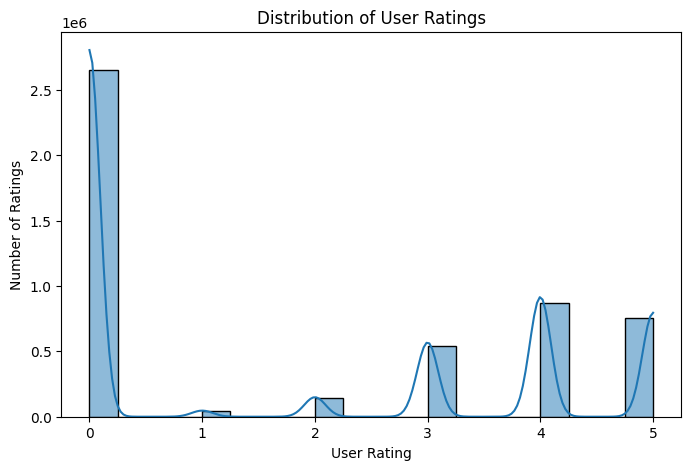

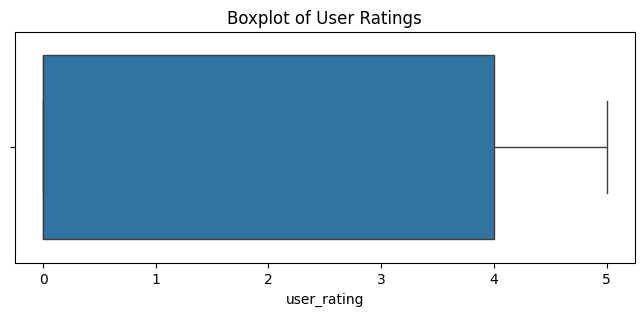

Mean: 1.8351714
Median: 0.0
Std: 2.0646872366583477


In [3]:
print(df["user_rating"].value_counts().sort_index())
plt.figure(figsize=(8,5))

sns.histplot(
    df["user_rating"],
    bins=20,
    kde=True
)

plt.title("Distribution of User Ratings")
plt.xlabel("User Rating")
plt.ylabel("Number of Ratings")
plt.show()

plt.figure(figsize=(8,3))

sns.boxplot(x=df["user_rating"])

plt.title("Boxplot of User Ratings")
plt.show()

print("Mean:", df["user_rating"].mean())
print("Median:", df["user_rating"].median())
print("Std:", df["user_rating"].std())

,0
user_id,
8e7e5b546a63cb9add8431ee6914cf59,34481
171e17ec537afc9e3548d1002072937a,30072
42453d4514faf1fb64c382aeb4c793d3,29012
a2b22e891349dd421f0d1589aa97b807,25764
06fe207046c7e8fe7ad2068956d77e75,25731
2d13f995e7b765b08e09b3f9e52c32e0,16765
946be44293a01fee761a72dcd20bb380,12087
9a508ae6bc330925ea5342ca53241c81,11578
a39ed6df3c55179629668dcfe642165f,10869


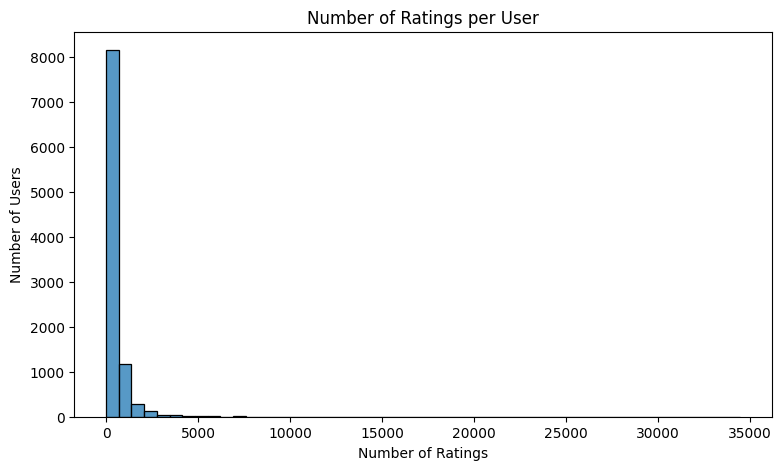

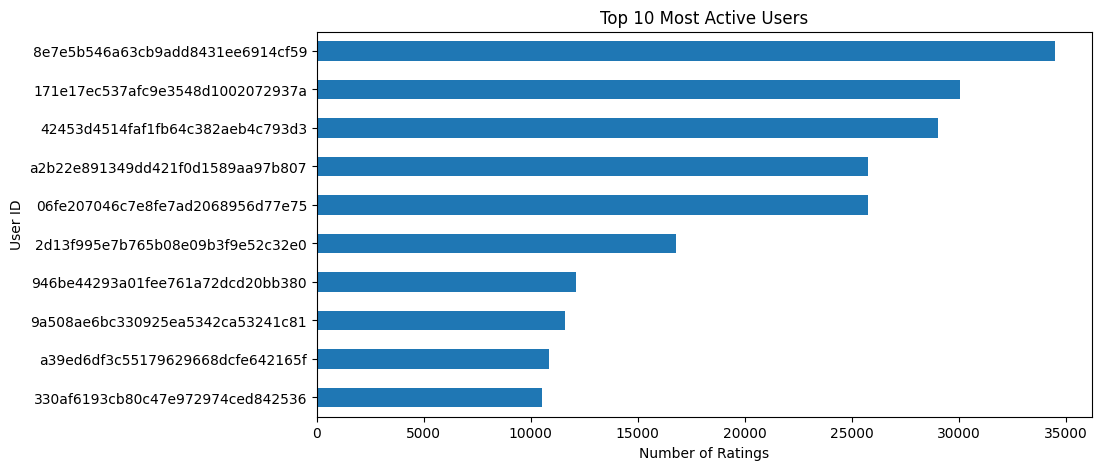

In [7]:
ratings_per_user = (
    df.groupby("user_id")
      .size()
      .sort_values(ascending=False)
)

display(ratings_per_user.head(20))

plt.figure(figsize=(9,5))

sns.histplot(
    ratings_per_user,
    bins=50
)

plt.title("Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

top_users = ratings_per_user.head(10)

plt.figure(figsize=(10,5))

top_users.sort_values().plot(kind="barh")

plt.title("Top 10 Most Active Users")
plt.xlabel("Number of Ratings")
plt.ylabel("User ID")
plt.show()

,,0
book_id,book_title,
2767052,The Hunger Games,5376
3,Harry Potter and the Philosopher's Stone,4923
2657,To Kill a Mockingbird,4340
41865,Twilight,4187
4671,The Great Gatsby,3924
6148028,Catching Fire,3893
7260188,Mockingjay,3825
5470,Nineteen Eighty-Four,3667
5,Harry Potter and the Prisoner of Azkaban,3619


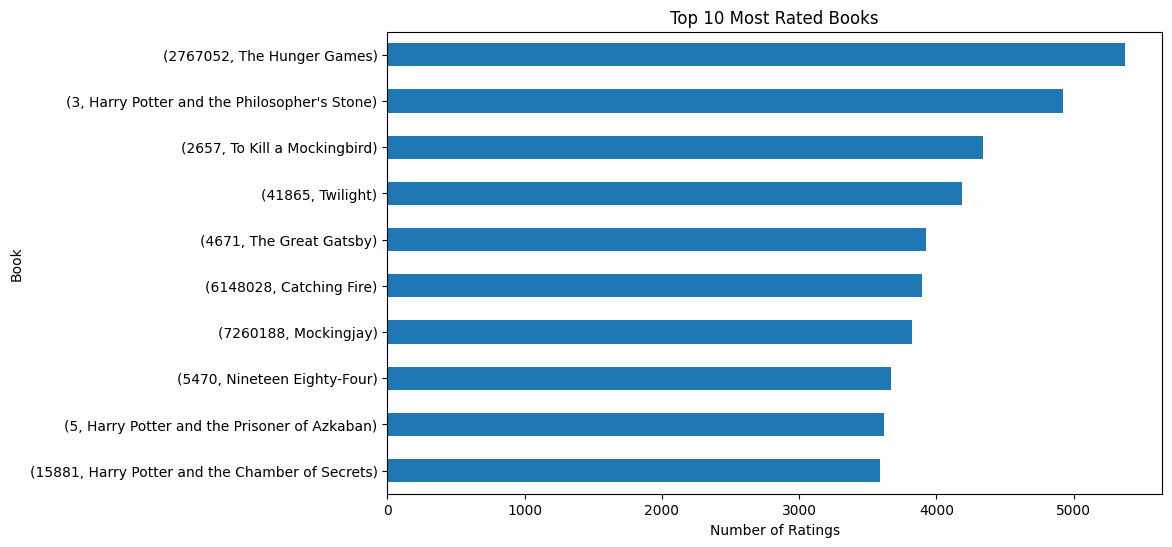

In [8]:
ratings_per_book = (
    df.groupby(["book_id", "book_title"])
      .size()
      .sort_values(ascending=False)
)

display(ratings_per_book.head(20))

top_books = ratings_per_book.head(10)

plt.figure(figsize=(10,6))

top_books.sort_values().plot(kind="barh")

plt.title("Top 10 Most Rated Books")
plt.xlabel("Number of Ratings")
plt.ylabel("Book")
plt.show()

In [9]:
book_stats = (
    df.groupby(["book_id", "book_title"])
      .agg(
          num_ratings=("user_rating", "count"),
          avg_user_rating=("user_rating", "mean"),
          book_average_rating=("book_average_rating", "first")
      )
      .sort_values("num_ratings", ascending=False)
)

display(book_stats.head(20))

popular_books = book_stats[book_stats["num_ratings"] >= 50]

display(
    popular_books.sort_values(
        "avg_user_rating",
        ascending=False
    ).head(20)
)

,,num_ratings,avg_user_rating,book_average_rating
book_id,book_title,,,
2767052,The Hunger Games,5376,3.885417,4.34
3,Harry Potter and the Philosopher's Stone,4923,4.022953,4.45
2657,To Kill a Mockingbird,4340,3.381336,4.26
41865,Twilight,4187,3.095295,3.57
4671,The Great Gatsby,3924,3.036188,3.89
6148028,Catching Fire,3893,3.776522,4.30
7260188,Mockingjay,3825,3.457516,4.03
5470,Nineteen Eighty-Four,3667,2.818926,4.14
5,Harry Potter and the Prisoner of Azkaban,3619,3.961868,4.53


,,num_ratings,avg_user_rating,book_average_rating
book_id,book_title,,,
24494,The Calvin and Hobbes Lazy Sunday Book,76,4.302632,4.66
24813,The Calvin and Hobbes Tenth Anniversary Book,125,4.296000,4.63
90072,,222,4.270270,4.44
233691,The Far Side Gallery 3,76,4.223684,4.45
99298,Harry Potter Boxed Set Books 1-4,71,4.211268,4.66
44186,The Monster at the End of This Book,246,4.191057,4.45
10,"Harry Potter Collection (Harry Potter, #1-6)",50,4.160000,4.73
24814,It's a Magical World: A Calvin and Hobbes Collection,50,4.100000,4.75
270067,A Pocket for Corduroy,102,4.098039,4.29


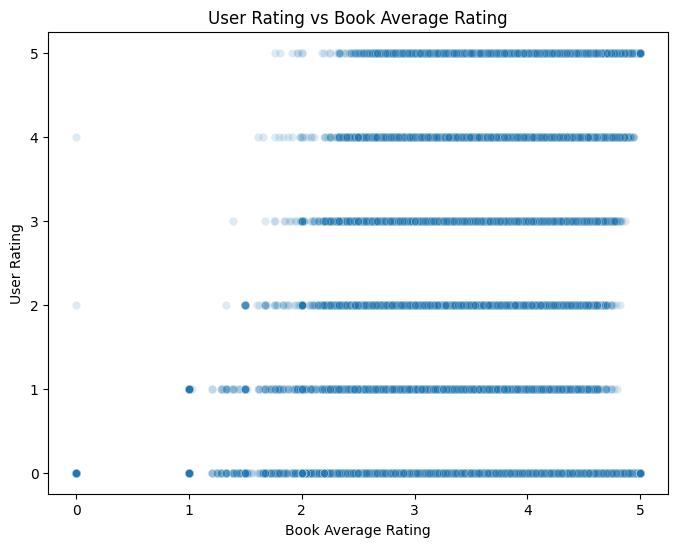

                     user_rating  book_average_rating
user_rating             1.000000             0.136217
book_average_rating     0.136217             1.000000


In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="book_average_rating",
    y="user_rating",
    alpha=0.15
)

plt.title("User Rating vs Book Average Rating")
plt.xlabel("Book Average Rating")
plt.ylabel("User Rating")
plt.show()

print(
    df[["user_rating", "book_average_rating"]]
      .corr()
)

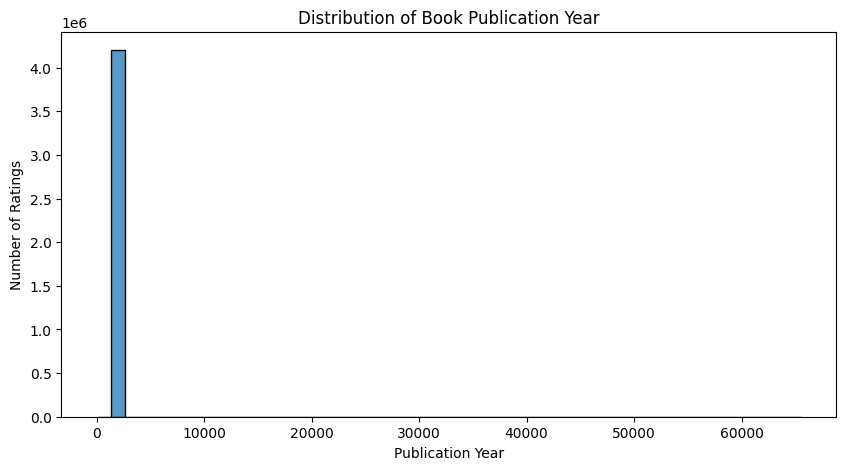

count    4.203377e+06
mean     2.007635e+03
std      8.218270e+01
min      0.000000e+00
25%      2.004000e+03
50%      2.010000e+03
75%      2.013000e+03
max      6.553500e+04
Name: book_publication_year, dtype: float64


,book_publication_year
4604791,65535.0
4629,65535.0
1772640,65535.0
93705,65535.0
2181977,21016.0
252173,21012.0
1371389,21012.0
382328,20187.0
3655033,20140.0
3889262,20136.0


In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["book_publication_year"].dropna(),
    bins=50
)

plt.title("Distribution of Book Publication Year")
plt.xlabel("Publication Year")
plt.ylabel("Number of Ratings")
plt.show()

print(
    df["book_publication_year"]
      .describe()
)

df["book_publication_year"].sort_values().head(20)
df["book_publication_year"].sort_values(ascending=False).head(20)

,publication_decade,avg_rating,num_ratings
0,0.0,1.483871,31
1,10.0,1.059603,151
2,20.0,2.500000,6
3,30.0,3.000000,4
4,40.0,5.000000,1
...,...,...,...
83,20130.0,1.000000,3
84,20140.0,5.000000,1
85,20180.0,0.000000,1
86,21010.0,0.000000,3


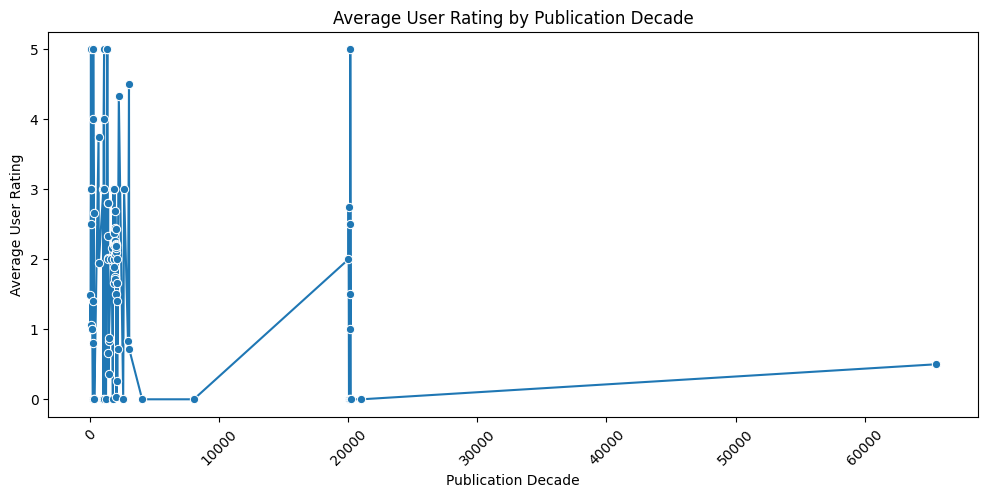

In [12]:
df["publication_decade"] = (
    df["book_publication_year"] // 10 * 10
)

decade_stats = (
    df.groupby("publication_decade")
      .agg(
          avg_rating=("user_rating", "mean"),
          num_ratings=("user_rating", "count")
      )
      .reset_index()
)

display(decade_stats)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=decade_stats,
    x="publication_decade",
    y="avg_rating",
    marker="o"
)

plt.title("Average User Rating by Publication Decade")
plt.xlabel("Publication Decade")
plt.ylabel("Average User Rating")
plt.xticks(rotation=45)
plt.show()

,count
fiction,4044393
romance,2159197
paranormal,1784258
fantasy,1777569
young-adult,1538271
biography,1428662
history,1426243
historical fiction,1414215
crime,1090085
thriller,1086955


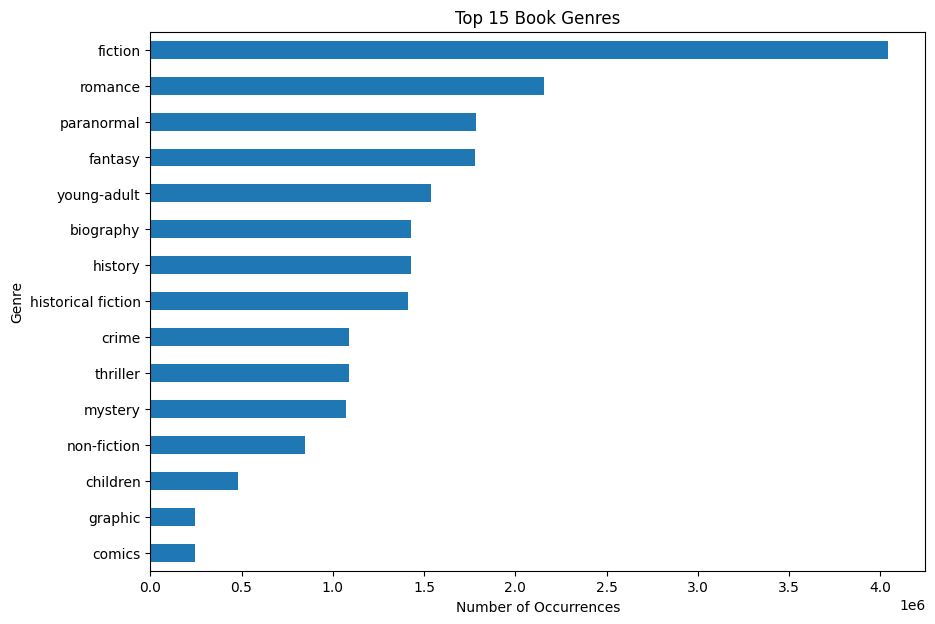

In [13]:
genre_cols = [
    "book_genre_1",
    "book_genre_2",
    "book_genre_3",
    "book_genre_4",
    "book_genre_5"
]

genres = df[genre_cols].stack().dropna()

genre_counts = genres.value_counts()

display(genre_counts.head(20))

plt.figure(figsize=(10,7))

genre_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Book Genres")
plt.xlabel("Number of Occurrences")
plt.ylabel("Genre")
plt.show()

In [14]:
genre_df = df[["user_rating"] + genre_cols].melt(
    id_vars="user_rating",
    value_name="genre"
)

genre_df = genre_df.dropna(subset=["genre"])

genre_stats = (
    genre_df.groupby("genre")
            .agg(
                avg_rating=("user_rating", "mean"),
                num_ratings=("user_rating", "count")
            )
            .sort_values("num_ratings", ascending=False)
)

display(genre_stats.head(20))

popular_genres = genre_stats[
    genre_stats["num_ratings"] >= 100
].sort_values(
    "avg_rating",
    ascending=False
)

display(popular_genres.head(15))

,avg_rating,num_ratings
genre,,
fiction,1.922383,4044393
romance,1.812944,2159197
paranormal,2.021712,1784258
fantasy,2.022823,1777569
young-adult,1.956119,1538271
biography,1.694766,1428662
history,1.693338,1426243
historical fiction,1.686316,1414215
crime,1.854147,1090085


,avg_rating,num_ratings
genre,,
children,2.478569,480232
graphic,2.300798,246328
comics,2.300425,243522
poetry,2.043370,136362
fantasy,2.022823,1777569
paranormal,2.021712,1784258
young-adult,1.956119,1538271
fiction,1.922383,4044393
crime,1.854147,1090085


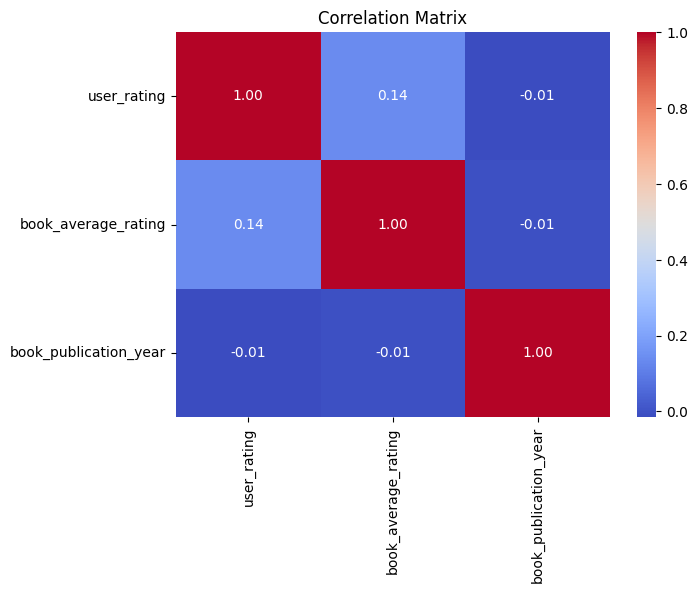

In [15]:
numeric_cols = [
    "user_rating",
    "book_average_rating",
    "book_publication_year"
]

plt.figure(figsize=(7,5))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

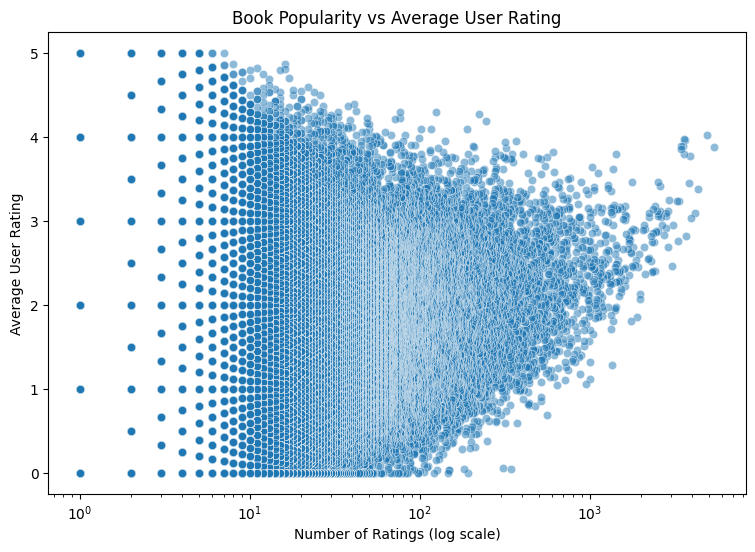

In [16]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=book_stats,
    x="num_ratings",
    y="avg_user_rating",
    alpha=0.5
)

plt.xscale("log")

plt.title("Book Popularity vs Average User Rating")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Average User Rating")

plt.show()

In [17]:
print("Number of users:", df["user_id"].nunique())
print("Number of books:", df["book_id"].nunique())
print("Number of ratings:", len(df))

density = (
    len(df) /
    (df["user_id"].nunique() * df["book_id"].nunique())
)

print("User-book matrix density:", density)

Number of users: 9913
Number of books: 756283
Number of ratings: 5000000
User-book matrix density: 0.0006669304706586395
